# [IAPR][iapr]: Lab 3 ‒  Classification


**Group ID:** 64

**Author 1 (sciper):** Andrew Brown (370751)  
**Author 2 (sciper):** Nour Lachat (302397)   
**Author 3 (sciper):** Henry Farrell (402247) 

**Release date:** 02.04.2025   
**Due date:** 16.04.2025 (11:59 pm)


## Key Submission Guidelines:

- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`  
- **Only groups of three will be accepted**, except in exceptional circumstances.  
- **You are not allowed to use any libraries** other than those provided in this notebook.  
- **TAs must be able to run your code from start to finish without any issues.**  
- **Failure to follow these guidelines may result in point deductions** during grading.  


[iapr]: https://github.com/LTS5/iapr

In [25]:
!pip install numpy -q
!pip install matplotlib -q
!pip install pillow -q
!pip install pandas -q
!pip install scikit-learn -q
!pip install tqdm -q
!pip install gdown -q

In [26]:
# Check is at least python 3.9
import sys 
#assert (sys.version_info.major == 3) and (sys.version_info.minor == 9)

Please take note that PyTorch will be utilized in this lab. PyTorch is a widely recognized library for deep learning. Prior to commencing the lab, we kindly ask you to review this quick tutorial available [here](https://pytorch.org/tutorials/beginner/basics/intro.html).

In [27]:
import platform

# Get os name
os_name = platform.system().lower()

# OS X
if os_name == 'darwin':
    print("Detected OS X")
    %pip install torch torchvision torchaudio -q
    
#Windows
elif os_name == 'windows':
    print("Detected Windows")
    %pip install torch torchvision torchaudio -q
    
# Linux  
else:
    print("Detected Linux")
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

Detected Windows
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Import main packages
import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from typing import Optional, Callable
from sklearn.metrics import accuracy_score, f1_score
from sklearn.covariance import LedoitWolf

from utils.lab_03_utils import *

# Real-World Image Classification in Histopathology [30 points]

Supervised learning for classifying histopathology images, despite its capabilities, faces significant challenges. A primary obstacle is its reliance on labeled data, which is often scarce and costly to acquire due to the need for expert annotations. This scarcity can impede model performance, particularly when dealing with uncommon diseases or subtle pathological patterns. Moreover, supervised models may struggle with generalization to unseen data or variations in tissue staining protocols. 

This lab will concentrate on constructing classification models tailored for histopathology using the least labeled data possible. Since the lab does not center on computing descriptors for the images, only image features will be provided. Specifically, we utilized [CTransPath](https://github.com/Xiyue-Wang/TransPath), one of the most robust and precise existing image feature extractors in histopathology, as the descriptor. Your focus will be on classifying these features for downstream tasks crucial to histopathological analysis.

Before starting, download the data by running the following cell and make sure the data are located as follows:
```code
├── labs
│   └──lab_03_iapr.ipynb
└── data
    └── data_lab_03
        ├── part_01
        │    ├── k16_train.pth
        │    ├── k16_val.pth
        │    ├── k16_test.pth
        │    ├── k16.png
        │    └── k16.svg
        └── part_02
            ├── acinar.png
            ├── solid.png
            ├── wsi.png
            ├── DHMC_0001.png
            ├── DHMC_0007.png
            ├── dhmc_train.pth
            ├── dhmc_val.pth
            └── dhmc_test.pth
```

In [29]:
download_data()

## Part 1 - Tumor, Stroma Classification in Colorectal Cancer Histopathology (11 points)

Colorectal cancer ranks among the most prevalent cancers affecting both men and women. Accurate diagnosis, supplemented with prognostic and predictive biomarker information, plays a pivotal role in patient monitoring and facilitating personalized treatment approaches. One crucial biomarker is the Tumor/Stroma ratio (TSR) observed in unhealthy colon tissues. This ratio serves as an indicator of cancer invasiveness, with higher ratios correlating to increased invasiveness and, consequently, diminished patient survival probabilities.

Traditionally, pathologists assess the TSR by visually inspecting unhealthy tissue samples under a microscope, relying on their expertise to estimate the ratio. However, given the large volume of samples and the occasional lack of precision in estimations, there arises a pressing need for automated recognition of various tissue types within histological images. The development of a multi-class classifier becomes imperative to accurately identify the diverse tissue types present. Typically, these tissue types include TUMOR, STROMA, LYMPHO (lymphocytes), MUCOSA, COMPLEX (complex stroma), DEBRIS, ADIPOSE, and EMPTY (background).

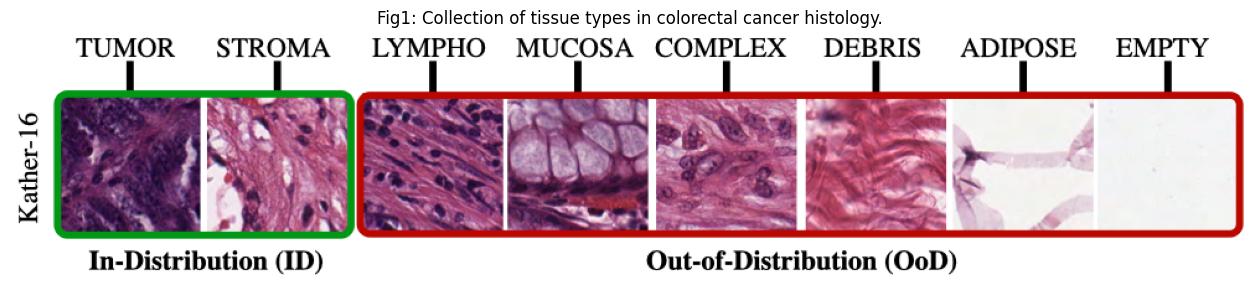

In [30]:
show_figure("../data/data_lab_03/part_01/k16.png","Fig1: Collection of tissue types in colorectal cancer histology.",(16,4))

Until now, state-of-the-art methodologies in histology have predominantly relied on deep-learning-based supervised learning techniques. However, a significant drawback of such an approach lies in the requirement for access to a meticulously annotated training dataset. Annotating histological data poses considerable challenges—it is a time-consuming process that demands the expertise of pathologists. Moreover, annotators are compelled to label every tissue type, even though only two (TUMOR and STROMA) are of primary interest.

To address these challenges, we propose an alternative approach. To streamline the annotation process, we task the annotator with labeling only the tissues of interest (TUMOR and STROMA), and discarding the rest. Subsequently, we aim to train a binary classifier capable of automatically recognizing these specific tissues during testing. This novel approach seeks to alleviate the burden of annotation while still enabling accurate identification of the critical tissue types. In this section, we will proceed with implementing and evaluating this proposed methodology.

In [31]:
train_x, train_y = load_data("k16_train.pth")
val_x, val_y = load_data("k16_val.pth")

Distribution of data in train set
#Tumor examples: 439
#Stroma examples: 439
Distribution of data in val set
#Tumor examples: 93
#Stroma examples: 93


### 1.1 Binary classifier with Mahalanobis distance [2.5 pts]

Your task is to construct this binary classifier utilizing the Mahalanobis distance as taught in class. Begin by executing the cell below to load the training and validation features for TUMOR and STROMA. These features have been computed using a self-supervised model tailored for histopathology, known as CTransPath. Note that label `0` corresponds to TUMOR and label `1` to STROMA:

* **Q1 (1 pt)**: Complete the `fit` method in `MahalanobisClassifier`. This method calculates the parameters necessary for the Mahalanobis Classifier when fitted to the training data.
* **Q2 (1 pt)**: Complete the `predict` method in `MahalanobisClassifier`. This method is responsible for predicting the class for each test feature as well as the distance to class means using the Mahalanobis distance method.

**Note**: It is forbidden to use any prebuilt Mahalanobis distance function. You may only use `LedoitWolf` in `sklearn.covariance` for computing a stable covariance matrix.

In [32]:
class MahalanobisClassifier:
    """Mahalanobis based classifer"""

    def __init__(self):
        """
        Attributes:
            means (torch.tensor): (n_classes, d) Mean of the features for each class
            inv_covs (torch.tensor): (n_classes, d, d) Inverse of covariance matrix across d features for each class   
        """
        super().__init__()
        self.means = None
        self.inv_covs = None
        
    def fit(self, train_x : torch.Tensor, train_y : torch.Tensor):
        """Computes parameters for Mahalanobis Classifier (self.mean and self.cov), fitted on the training data.

        Args:
            train_x (torch.Tensor): (N, d) The tensor of training features
            train_y (torch.Tensor): (N,) The tensor of training labels
        """

        # Define number of classes
        n_classes = len(np.unique(np.unique(train_y)))
        n, d = train_x.shape
        
        # Set default values
        means = torch.zeros((n_classes, d), dtype=train_x.dtype)
        inv_covs = torch.ones((n_classes, d, d), dtype=train_x.dtype)
        
        # ------------------
        # Convert to numpy for sklearn compatibility
        train_x_np = train_x.numpy()
        train_y_np = train_y.numpy()

        classes = np.unique(train_y_np)

        for i, c in enumerate(classes):
            # Get samples for the curent class
            class_samples = train_x_np[train_y_np == c]

            # Compute class mean
            means[i] = torch.from_numpy(np.mean(class_samples, axis=0))

            # Compute class covariance matrix
            lw = LedoitWolf().fit(class_samples)

            cov_matrix = lw.covariance_

            # Compute inverse covariance matrix
            inv_covs[i] = torch.from_numpy(np.linalg.pinv(cov_matrix))
        
        # ------------------
            
        self.means = means
        self.inv_covs = inv_covs



    def predict(self, test_x : torch.Tensor) -> torch.Tensor:
        """Predicts the class of every test feature, using the Mahalanobis Distance

        Args:
            test_x (torch.Tensor): (N, d) The tensor of test features

        Returns:
            preds (torch.Tensor): (N,) The predictions tensor (id of the predicted class {0, 1, ..., n_classes-1})
            dists (torch.Tensor): (N, n_classes) Mahalanobis distance from sample to class means
        """

        # Define default output value
        N, d = test_x.shape
        dists = torch.zeros((N, self.means.shape[0]), dtype=test_x.dtype)
        preds = torch.zeros(N, dtype=test_x.dtype)
        
        # ------------------
        # Compute Mahalanobis distance for each test sample to each of the classes
        for i in range(N): 
            x = test_x[i] # Current test sample
            for j in range(self.means.shape[0]):

                # Calculate Difference Vector
                diff = x - self.means[j]

                # Calculate Mahalanobis distance
                dist = torch.sqrt(diff @ self.inv_covs[j] @ diff.T)
                
                # Store distance
                dists[i, j] = dist

            # Get the class with the minimum distance
            preds[i] = torch.argmin(dists[i])
        # ------------------

        return preds, dists

* **Q3 (0.5 pt)**: After fitting your classifier on the training data, compute the accuracy of the validation data. Are you satisfied with the results?
    * **Answer**: The validation Set Accuracy is 98.92%. This is good, but not good enough. We are dealing with cancer so we want 100% accuracy. It seems the Mahalanobis distance is a good binary classifier most of the time, but not all of the time because there are 2 tumor samples, as can be seen below, that are a bit too integrated into the stroma dataset to be reasonably grouped as tumors. This is likly due to other tissue types present, which cannot be manually filtered out. This is unacceptable. Therefore a different measure than Mahalanobis distance is needed to increase the accuracy of our classification to 100%.

C:\Users\andre\AppData\Local\Temp\ipykernel_27112\244597503.py:85: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3729.)
  dist = torch.sqrt(diff @ self.inv_covs[j] @ diff.T)


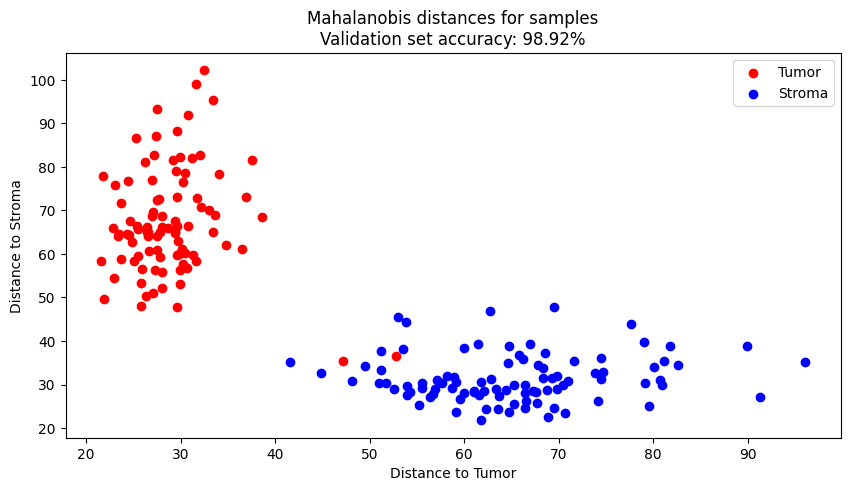

In [33]:
################################################################
############################ TEST ##############################
################################################################

mahalanobis_classifier(
    MahalanobisClassifier, train_x, train_y, val_x, val_y,
    cls_name=["Tumor", "Stroma"], colors=["r", "b"],
)

### 1.2 Out-of-Distribution detection with Mahalanobis distance [3.5 pts]

Your classifier appears to perform well. However, during testing, it's possible for other tissue types to be present, which cannot be manually filtered out. Moreover, these tissue types may not be recognized by the model as they fall outside the labeled training distribution (It is the consequence of the laziness of the annotators ;)). Therefore, it's crucial to filter out these out-of-distribution (OoD) samples.

One approach to OoD detection involves computing an OoD-ness score for each test example. This score should be low for in-distribution (ID) examples and high for OoDs. Subsequently, a threshold is defined, for which any example with a greater OoD-ness is discarded, while those below it are forwarded to the model for prediction. An example of an OoD-ness score is the minimum Mahalanobis distance to means.

* **Q1 (0.5 pts)**: Why do you think the minimum Mahalanobis distance is a good OoD-ness score?
    * **Answer**: The Mahalanobis distance works well for OOD detection because it actually understands the data’s structure, unlike Euclidean distance, which treats all features equally. By using the covariance matrix, it normalizes features by their variance and accounts for correlations between them—downweighting noisy, high-variance directions while emphasizing more important ones. It also rescales the feature space in a way that keeps distances meaningful even in high dimensions, where Euclidean distance fails. This makes it a statistically solid way to measure OOD-ness.

Start by running the cell below to load the test set. It comprises TUMOR and STROMA samples, along with other tissue types. Note that OoD tissues types are labeled to `-1`.

In [34]:
test_x, test_y = load_data("k16_test.pth")

Distribution of data in test set
#Tumor examples: 93
#Stroma examples: 93
#OoD examples: 558


* **Q2 (0.5 pts)**: We create a new classifier `MahalanobisOODClassifier` that inherits from the previous one. Reimplement the function `predict` such that it returns as well the OoD scores. We define the `ood_scores` as the minimum Mahalanobis distance from the classifier. Your accuracy results should be the same as before.

In [35]:
class MahalanobisOODClassifier(MahalanobisClassifier):
    """Predicts the class of every test feature, using the Mahalanobis Distance

    Args:
        test_x (torch.Tensor): (N x d) The tensor of test features

    Returns:
        preds (torch.Tensor): (N,) The predictions tensor (id of the predicted class {0, 1, ..., n_classes-1})
        dists (torch.Tensor): (N, n_classes) Mahalanobis distance from sample to class means
        ood_scores (torch.Tensor): (N,) Score of OoDness as the minimal distance from the sample to classes
    """

    def predict(self, test_x : torch.Tensor) -> torch.Tensor:
        
        # Get super prediction (from MahalanobisClassifier)
        preds, dists = super().predict(test_x=test_x)
        N = preds.shape[0]

        # Assign dummy values to scores
        ood_scores = np.zeros(N)
        
        # ------------------
         # Compute OOD scores (minimum distance across all classes) as the OoDness score
        ood_scores = torch.min(dists, dim=1)[0]
        # ------------------
        
        return preds, dists, ood_scores


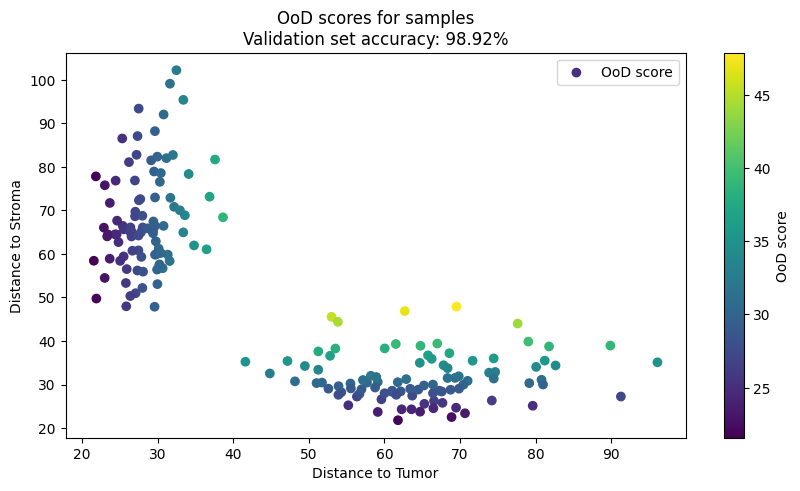

In [36]:
################################################################
############################ TEST ##############################
################################################################

classifier_ood, val_y_ood_scores=mahalanobis_ood_classifier(
    MahalanobisOODClassifier, train_x, train_y, val_x, val_y,
    cls_name=["Tumor", "Stroma"], colors=["r", "b"],
)


* **Q3 (0.5 pts)**: Based on the validation set OoD scores, determine a threshold for the minimum Mahalanobis distance such that 95% of the validation samples are identified as ID.

In [37]:
def get_ood_threshold(ood_scores, quantile=0.95):
    """ Get OoD threshold based on measured scores and quantile

    Args:
        ood_scores (torch.Tensor): (N, ) N measured OoDness scores
        quantile (float): Percentage of samples that are considered as in distribution
    """

    # Set default value
    threshold = 0

    # ------------------
    # Compute threshold based on quantile
    threshold = np.quantile(ood_scores, quantile)
    # ------------------

    return threshold

Validation threshold 95% = 38.87


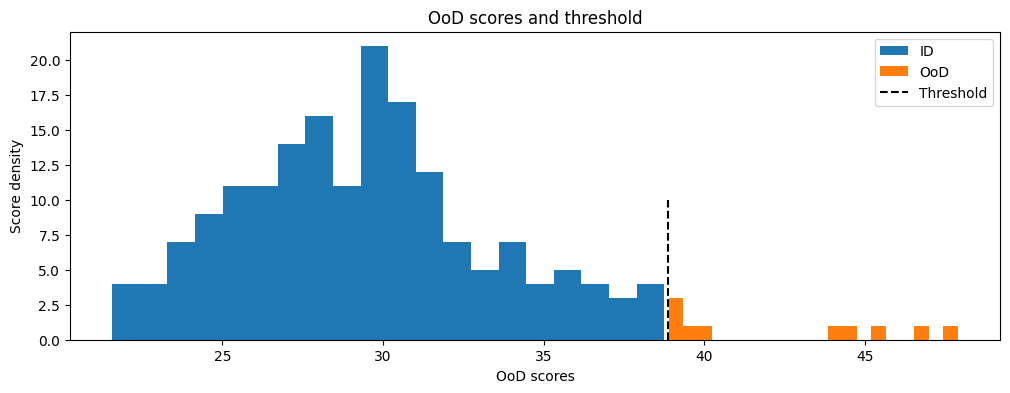

In [38]:
################################################################
############################ TEST ##############################
################################################################

threshold_val = check_threshold(get_ood_threshold,val_y_ood_scores)

* **Q4 (2 pts)**: Complete the function `compute_metrics` that computes the recall for TUMOR, STROMA, and OoD examples as well as the average recall over the 3 classes. To do so, you need to consider OoDs as a third class by assigning the prediction `-1` to filtered-out examples based on your threshold. Based on your results, conclude on the feasibility of the proposed pipeline. Propose a solution that would require the least annotation possible but that could significantly increase your OoD recall.
    * **Answer**: Tumor Recall (98.92%) is nearly perfect  which suggests the tumors have distinct featues that are easily separable with this pipeline. Stroma Recall (92.47%) is slightly lower than tumor recall but still strong. The potential confusion in this case is likely due to stroma patches misclassified as OoD if their features slightly deviate too much. OOD Recall (86.02%) is the weakest, which suggests the OOD features are falling close to tumor/stroma clusters in the feature space or that some ambiguous OOD tissue artifacts are resembling the real classes. Our average recall (92.47%) is good but skewed due to the strong Tumor Recall. The adjusted pieline should focus on improving OOD recall to balance this. Some suggestions to improve the pipeline we have are using **class-specific thresholding** instead of 1 global threshold and using data augmentation to make the classifier more robust via random variations and feature engineering to highlight OOD features such texture, color, etc.

In [39]:
def compute_metrics(y, y_hat, ood_scores, threshold):
    """ Compute recall for tumor, stroma, and OoD as well as the average recall.

    Args:
        y (torch.Tensor): (N) Class ground truth {-1, 0, 1, ..., n_classes}
        y_hat (torch.Tensor): (N,) Class predictions {0, 1, ..., n_classes}
        ood_scores (torch.Tensor): (N, ) N measured OoDness scores
        threshold (float): OoD threshold
    """
    # Define variable with dummy values 
    recall_tumor = 0
    recall_stroma = 0
    recall_ood = 0
    avg_recall = 0
    
    # ------------------
    # Convert all inputs to numpy if they're tensors
    y_np = y.numpy() if torch.is_tensor(y) else y
    y_hat_np = y_hat.numpy() if torch.is_tensor(y_hat) else y_hat
    ood_scores_np = ood_scores.numpy() if torch.is_tensor(ood_scores) else ood_scores
    threshold_np = threshold.item() if torch.is_tensor(threshold) else threshold
    
    # Mark predictions as OOD (-1) if their score exceeds threshold
    y_hat_ood = np.where(ood_scores_np > threshold_np, -1, y_hat_np)
    
    # Calculate recalls
    recall_tumor = np.mean((y_hat_ood == 0) & (y_np == 0)) / np.mean(y_np == 0)
    recall_stroma = np.mean((y_hat_ood == 1) & (y_np == 1)) / np.mean(y_np == 1)
    recall_ood = np.mean((y_hat_ood == -1) & (y_np == -1)) / np.mean(y_np == -1)
    
    # Handle potential division by zero
    recall_tumor = 0 if np.isnan(recall_tumor) else recall_tumor
    recall_stroma = 0 if np.isnan(recall_stroma) else recall_stroma
    recall_ood = 0 if np.isnan(recall_ood) else recall_ood
    
    # Calculate average recall
    avg_recall = (recall_tumor + recall_stroma + recall_ood) / 3

    # ------------------

    return recall_tumor, recall_stroma, recall_ood, avg_recall


Tumor recall: 98.92%
Stroma recall: 92.47%
OoD recall: 86.02%
Average recall: 92.47%


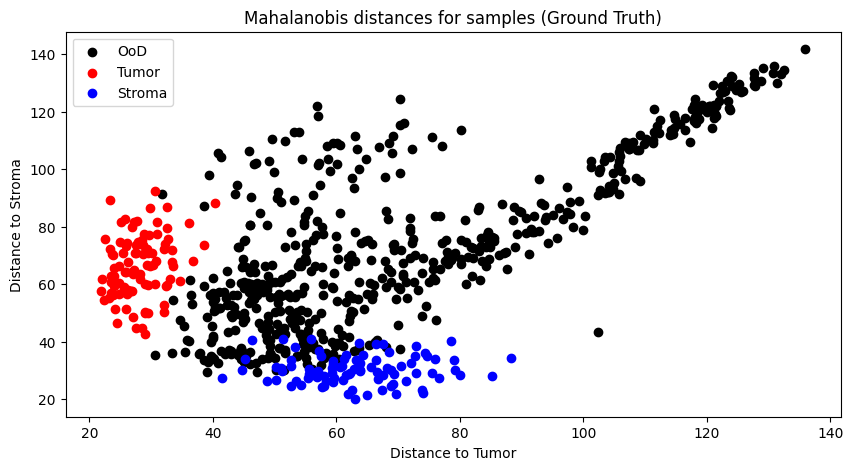

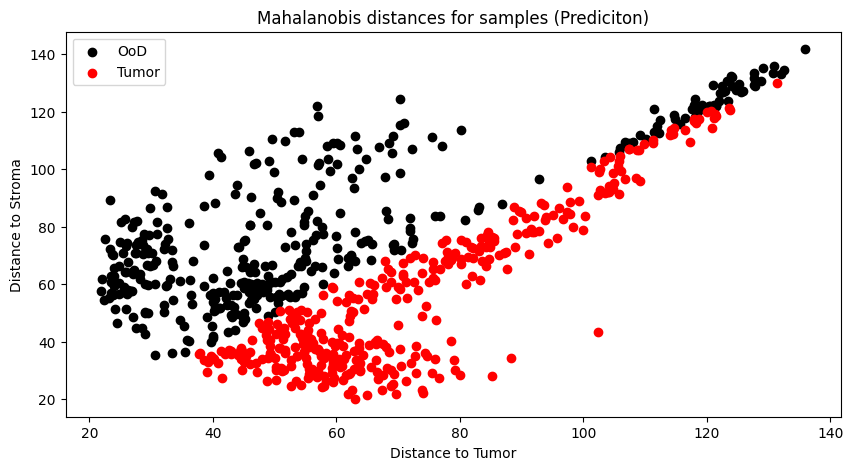

In [40]:
################################################################
############################ TEST ##############################
################################################################

# Predictions on test set
test_y_dist, test_y_hat = eval_test(classifier_ood,compute_metrics, test_x,test_y,threshold_val)

### 1.3 Out-of-Distribution detection with k-NN [5 pts]

Let's explore another technique based on k-Nearest Neighbors (k-NN). The features utilized have been extracted from a self-supervised model, known for their efficacy as k-NN classifiers. This motivates us to implement a k-NN classifier for identifying TUMOR and STROMA. Additionally, the k-NN distance serves as a suitable OoD-ness score, aligning well with our task requirements.

* **Q1 (2 pts)**: Complete the `fit` and `predict` functions in `kNNClassifier`. Also, assign your own handcrafted OoD score in `predict`. We recommend to use `top_k` function from torch ([doc](https://pytorch.org/docs/stable/generated/torch.topk.html)). When using k>1, use majority voting to select the winning class.

**Note**: It is forbidden to use any prebuilt k-NN classifier function.

In [41]:
class kNNClassifier:
    """k-NN based classifier"""

    def __init__(self, k : int):
        """
        Args:
            k (int): The number of neighbors to consider for the classification
            features (torch.Tensor): (N, d) feature of the N train samples
            labels (torch.Tensor): (N,) labels for train samples
        """
        self.k = k
        self.features = None
        self.labels = None

    def fit(self, train_x : torch.Tensor, train_y : torch.Tensor):
        """Store training data parameters (features and labels) for k-NN classifier.

        Args:
            train_x (torch.Tensor): (N, d) The tensor of training features
            train_y (torch.Tensor): (N,) The tensor of training labels
        """
        
        # Get size and default values
        N, d = train_x.shape
        features = torch.zeros((N, d))
        labels = torch.zeros(N)
        
        # ------------------
        # Simply store the training data
        features = train_x.clone()
        labels = train_y.clone()
        # ------------------

        self.features = features
        self.labels = labels

    def predict(self, test_x: torch.Tensor) -> torch.Tensor:
        """Predicts the class of every test feature, using the k-NN"""
        N, d = test_x.shape
        preds = torch.zeros(N, dtype=torch.long)
        ood_scores = torch.zeros(N)
        
        # ------------------
        # Compute distances between test and train features
        distances = torch.cdist(test_x, self.features)
        
        # Get k nearest neighbors for each test sample
        _, indices = torch.topk(distances, k=self.k, largest=False, dim=1)

        # Get labels of nearest neighbors
        neighbor_labels = self.labels[indices]

        # Get the most common label among the neighbors (majority vote)
        if self.k == 1:
            preds = neighbor_labels.squeeze(1)
        else:
            # Get number of classes (convert max to int first)
            n_classes = int(torch.max(self.labels).item()) + 1
            counts = torch.zeros((N, n_classes), dtype=torch.long)
            
            for i in range(N):
                unique, cnt = torch.unique(neighbor_labels[i], return_counts=True)
                counts[i, unique.long()] = cnt
            preds = torch.argmax(counts, dim=1)
    
        # OOD score: average distance to k nearest neighbors
        ood_scores = torch.mean(distances.gather(1, indices), dim=1)
        # ------------------
        
        return preds, ood_scores

* **Q2 (1 pt)**: Find the best `k` among `[1, 3, 5, 9, 15, 25]` based on the validation set. What is the best `k` and accuracy?
    * **Answer**: The best k is k=3 with an accuracy of 99.46%. The next highest k is k=5 with an accuracy of 98.92%. 

In [42]:
# Best k for knn fitting (to find among suggested ks)

def find_best_k(ks,kNNClassifier: Callable,train_x: torch.Tensor, train_y: torch.Tensor, val_x: torch.Tensor, val_y: torch.Tensor):
    best_k = 0
    best_accuracy = 0.
    # Iterate over ks
    for k in ks:

        # ------------------
        classifier = kNNClassifier(k=k)
        classifier.fit(train_x, train_y)
        preds, _ = classifier.predict(val_x)
        
        accuracy = accuracy_score(val_y.numpy(), preds.numpy())
        print(f"Accuracy for k={k}: {accuracy:.4f}")
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k  # Fixed: assign current k, not the whole list
        # ------------------
        
        continue

    return best_k, best_accuracy

In [43]:
################################################################
############################ TEST ##############################
################################################################

best_k, best_accuracy = check_best_k(find_best_k, kNNClassifier,train_x, train_y, val_x, val_y)

Accuracy for k=1: 0.9839
Accuracy for k=3: 0.9946
Accuracy for k=5: 0.9892
Accuracy for k=9: 0.9839
Accuracy for k=15: 0.9839
Accuracy for k=25: 0.9785

Best @ k: 3 -> 99.46% accuracy


* **Q3 (1 pt)**: Compute the threshold such that 95% of validation samples are detected as ID. 

In [44]:
def fit_knn(best_k, train_x, train_y, val_x, val_y):

    # best threshold
    threshold_val = 0
    # Predicted val ood scores
    val_y_ood_scores = torch.zeros(len(val_y))
    classifier = None 
    # ------------------
    # efine the classifier object
    classifier = kNNClassifier(k=best_k)

    # First fit the classifier on training data
    classifier.fit(train_x, train_y)
    
    # Get OOD scores for validation set
    _, val_y_ood_scores = classifier.predict(val_x)
    
    # Compute threshold for 95% ID retention
    threshold_val = torch.quantile(val_y_ood_scores, 0.95)
    # ------------------

    return classifier, threshold_val, val_y_ood_scores

Validation threshold 95% = 2.28


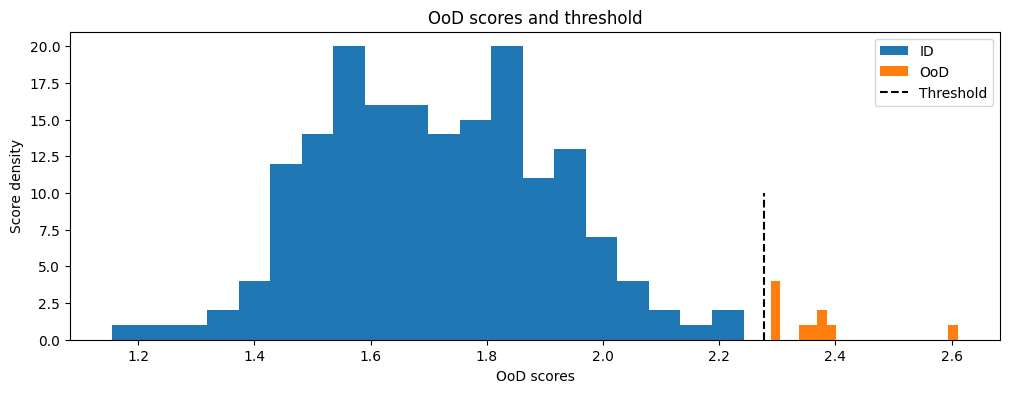

In [45]:
################################################################
############################ TEST ##############################
################################################################

# Plot ood scores and threshold
classifier, threshold_val, val_y_ood_scores = fit_knn(best_k, train_x, train_y, val_x, val_y)
plot_ood_scores(ood_scores=val_y_ood_scores, threshold=threshold_val)

* **Q4 (1 pt)**: We evaluate your classifier on the test set like in `1.2 Q4`. Is it better than Mahalanobis distance? Why?
    * **Answer**: KNN performs slightly better on tumor/stroma classification (100%/96.77% vs 98.92%/92.47%)
        Mahalanobis detects OOD samples more effectively (86.02% vs 81.72%)
        Average recall is nearly identical (92.83% vs 92.47%)

        The KNN's strength with tumors and stroma makes sense - it's looking for tissue patches that resemble known examples. Since tumors and stroma have pretty distinctive features under the microscope, this local matching approach works well. Mahalanobis, on the other hand, tries to model everything with broad statistical patterns, which might smooth over some important details in tissue structure.

        Where Mahalanobis shines is catching things that don't belong. It's not just looking at individual similarities like KNN, but taks into account all the features together. So when something comes along that doesn't fit the overall pattern of the training data - even if parts of it look familiar - Mahalanobis is more likely to flag it as suspicious. KNN can get fooled by OOD samples that happen to share some traits with normal tissue patches.

        In practice, which one is "better" depends on what matters more for your specific needs - pinpoint accuracy with known tissue types (KNN) or better detection of weird outliers (Mahalanobis).

In [46]:
################################################################
############################ TEST ##############################
################################################################

# Predictions on test set
eval_test_knn(classifier, compute_metrics, test_x,test_y,threshold_val)

Tumor recall: 100.00%
Stroma recall: 96.77%
OoD recall: 81.72%
Average recall: 92.83%


## Part 2 - Lung Adenocarcinoma Classification (19 points)

In the previous exercise, we successfully detected TUMOR and STROMA tissues using a minimum of labels. This allows us to compute the Tumor-Stroma Ratio (TSR), a valuable indicator for determining tumor grade and guiding treatment decisions. However, despite saving annotations, the need for hundreds of tumor/stroma annotations remains prohibitively expensive. Additionally, associating the TSR value with the correct tumor grade and treatment necessitates further algorithmic developments.

An alternative approach involves annotating entire tumor grades on Whole Slide Images (WSIs) and training a classifier directly. However, a significant challenge arises due to the immense size of WSIs, typically containing millions of pixels, which makes direct preprocessing infeasible for computers. To address this challenge, we partition the WSI into thousands of non-overlapping patches. Consequently, each WSI comprises thousands of patch features. However, classifying a conglomerate of features is inherently challenging, especially considering that each WSI may not necessarily contain the same number of patches.

As illustrated in Fig. 2, a highly effective method is to apply an aggregation pooling function, which transforms the pool of features into a single slide feature. Subsequently, we can train a simple classifier to classify the slides. In this section, your objective is to develop a classifier and various pooling methods for classifying WSIs of lung adenocarcinoma patterns.

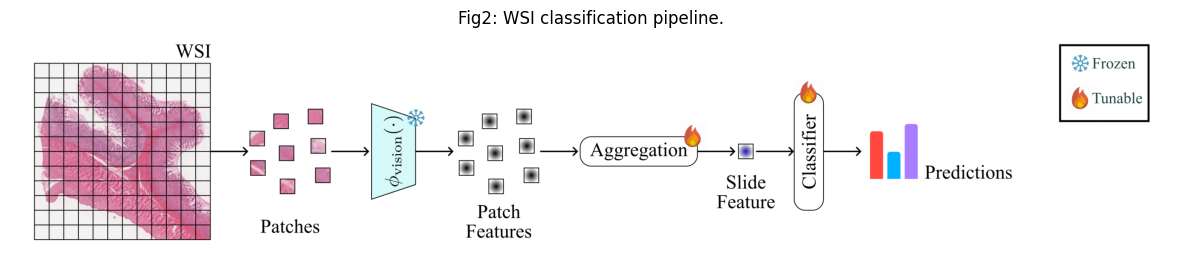

In [9]:
show_figure("../data/data_lab_03/part_02/wsi.png","Fig2: WSI classification pipeline.",(15,4))

### 2.1 Dataset [1 pt]

Your objective is to classify lung adenocarcinoma patterns, specifically acinar and solid patterns. Acinar adenocarcinoma typically exhibits glandular structures resembling small sacs when viewed under a microscope, as depicted in Fig. 3. These structures may appear irregular and crowded. Conversely, solid adenocarcinoma, as illustrated in Fig. 4, appears as solid sheets or nests of cells with little to no glandular differentiation.

You'll be working with a subset of the DHMC dataset, comprising 53 acinar examples and 48 solid examples. To assist you, we provide a training set and a validation set, representing 60% and 40% of the data, respectively. In this dataset, features of the patches composing each Whole Slide Image (WSI) have already been extracted using CTransPath. Your initial task is to prepare the data to be suitable for model training.

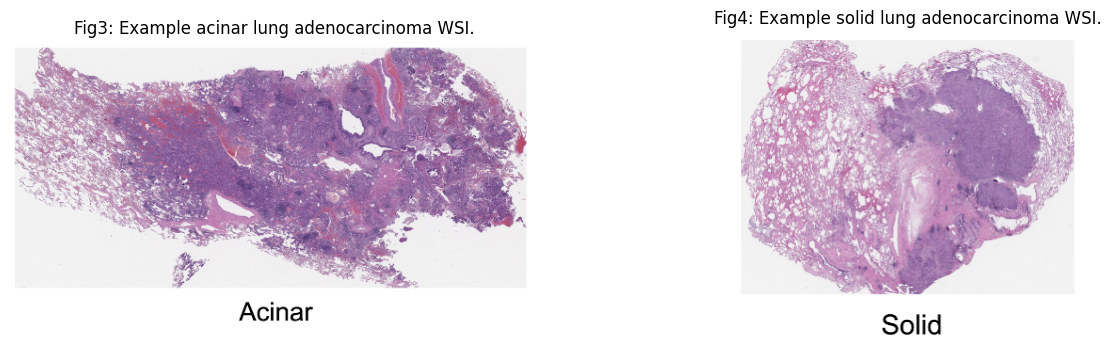

In [10]:
show_2_figures("../data/data_lab_03/part_02/acinar.png","Fig3: Example acinar lung adenocarcinoma WSI.","../data/data_lab_03/part_02/solid.png","Fig4: Example solid lung adenocarcinoma WSI.",(15,4))

* **Q1 (1 pt)**: Please complete the `DHMC2Cls` class. The class loads raw data from an external file and stores them in `raw_data`. You are required to implement the `__len__` and `__getitem__` functions. The `__len__` function should return the length M of the dataset, while the `__getitem__` function should return a tuple containing: (1) the patch features, (2) the WSI label, (3) the WSI id, and (4) the patch coordinates. Before proceeding take time to investigate the content of the raw data. It's important to note that in the training mode, you should only return the features and the label.

In [11]:
class DHMC2Cls(Dataset):
    """DHMC dataset using 2 classes"""

    def __init__(self, features_path : str, train : bool = False) -> None:
        """
        Attributes:
            raw_data (list of dict): (M) List of M slides raw data as dictionaries. 
            train (bool): True if data are the training set. False otherwise
            
        Args:
            features_path (str): The path to the features file
            train (bool): Whether it is the training dataset or not
        """
        
        super().__init__()
        # Load raw data from path
        self.raw_data = torch.load(features_path, weights_only=False)
        # Set if training or not
        self.train = train

    def __len__(self) -> int:
        """Returns the length of the dataset

        Returns:
            int: The length M of the dataset
        """

        n_data = 0
        
        # ------------------
        n_data = len(self.raw_data) 
        # ------------------
        
        return n_data
    
    def __getitem__(self, index : int):
        """Returns the entry at index from the dataset

        Args:
            index (int): the requested entry index of the dataset

        Returns:
            features (torch.Tensor): (N, d) Feature tensor of the selected slide with N patches and d feature dimensions
            label (int): Ground truth label {0, ..., n_classes}
            wsi_id (str): Name of the WSI as "DHMC_xxx" where xxx is a unique id of the slide (train == False only)
            coordinates (torch.Tensor): (N, 2) xy coordinates of the N patches of the selected slide (train == False only)
        """

        features = None
        label = None
        wsi_id = None
        coordinates = None
        
        # ------------------
        slide_data = self.raw_data[index]
        features = slide_data["patch_features"]
        label = slide_data["label"]
        
        if not self.train:
            wsi_id = slide_data["wsi_id"]
            coordinates = slide_data["patch_coordinates"]
        # ------------------
        
        if self.train:
            return features, label
        else:
            return features, label, wsi_id, coordinates

In the cell below, we create the dataset using DHMC2Cls and we test your training and validation datasets to check for inconsistencies. Your implementation should pass all tests. 

In [12]:
################################################################
############################ TEST ##############################
################################################################

train_loader, val_loader = create_dataset(DHMC2Cls)

Successful :)


### 2.2 Average Pooling [1 pt]

You will start with the simplest pooling method, i.e. average pooling. It simply consists of averaging the WSI patch features to form a single one representative of the WSI.

* **Q1 (1 pt)**: Complete the `forward` function in `AveragePooling`. Remember, it takes a set of WSI features with shape `(N x d)`, and should return a single WSI feature of shape `(1 x d)`.

In [13]:
class AveragePooling(nn.Module):

    def __init__(self) -> None:
        super().__init__()

    def forward(self, features : torch.Tensor):
        """ Perform mean along the first dimension of the tensor

        Args:
            features (torch.Tensor): (N, D) Feature to perform average pooling on
        Return:
            mean (torch.Tensor): (1, D) Features average over all patches
        """

        mean = None
        
        # ------------------
        mean = features.mean(dim=0, keepdim=True)
        # ------------------
        
        return mean

In [14]:
################################################################
############################ TEST ##############################
################################################################

sanity_check_avg(AveragePooling)

'Successful :)'

### 2.3 Classifier [8 pts]

Now that you have coded your first aggregation method, let's build the linear classifier.

* **Q1 (3 pts)**: 
    * Complete the `Classifier` class below. You should fill `__init__` which assigns the attributes. Attributes are :
        * `proj` is a nonlinear projection layer that adapts the features for the task. It is simply a linear layer that projects features of dimension `d` to features of lower dimension `H`. Then it is followed by a ReLU.
        * `pool`, the pooling function.
        * `fc`, the final linear classifier layer. 
    * Complete `forward` which given a pool of features of shape `(1 x N x d)` outputs the class prediction logits of shape `(1 x 2)`.

In [15]:
class LinearClassifier(nn.Module):

    def __init__(self, in_dim : int, H : int, n_classes : int, pooling_fn : nn.Module) -> None:
        """Constructs the linear classifier

        Attributes:
            proj (Callable): Projection of layer (N, d) -> (N, H)
            pool (Callable): Pooling layer (N, H) -> (1, H)
            fc (Callable): Classification layer (1, H) -> (1, n_classes)
            
        Args:
            in_dim (int): The dimension of input features
            H (int): Target dimension for the projection layer
            n_classes (int): The number of classes for the task
            pooling_fn (nn.Module): The pooling function to aggregate the features
        """
        super().__init__()

        proj_layer = None
        pool_layer = None
        fc_layer = None
        
        # ------------------
        proj_layer=nn.Sequential(
            nn.Linear(in_dim, H),
            nn.ReLU()
        )
        pool_layer = pooling_fn
        fc_layer = nn.Linear(H, n_classes)
        # ------------------

        self.proj = proj_layer
        self.pool = pool_layer
        self.fc = fc_layer
        

    def forward(self, x):
        """Forward path

        Args:
            x (torch.Tensor): (1, N, d) Input feature for a given slide with N patches
        Return:
            logits (torch.Tensor): (1, n_classes) Output logits for classification
        """

        logits = None
        
        # ------------------
        # Remove the batch dimension (1, N, d) -> (N, d)
        x = x.squeeze(0)

        # Apply the projection layer
        x = self.proj(x)

        # Apply the pooling layer
        x = self.pool(x)

        # Apply the final classification layer
        logits = self.fc(x)
        # ------------------

        return logits

In [16]:
################################################################
############################ TEST ##############################
################################################################

sanity_check_cls(LinearClassifier,AveragePooling)

'Successful :)'

The classifier is ready to train. It remains to write the code to optimize your model.

* **Q2 (2 pts)**: Please complete the `train` function below. This function should take `train_loader`, `val_loader`, `n_epochs`, and an `optimizer` as inputs. It is responsible for training the `model` and returning the best model checkpoint, best F1 score, and the epoch at which the best F1 score was achieved on the validatioACn set.

**Notes**: 
* Refer to this [tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) for guidance on training a classifier.
* To obtain the model checkpoint, simply call `model.state_dict()`.
* We provide you the `test` function, in utils file, that computes the F1 score on a given test dataset. **You should not modify it !!!**

In [40]:
def train(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, 
         n_epochs: int, optimizer: torch.optim.Optimizer):
    """Original docstring..."""
    
    # Initialize variables (unchanged)
    model_save_path = "best_model.pth"
    best_model = model.state_dict()
    best_epoch = 0
    best_f1 = 0
    train_losses = []
    val_losses = []
    val_f1s = []

    criterion = nn.CrossEntropyLoss()

    for epoch in range(n_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        
        for inputs, labels in train_loader:
            # Shape handling (critical fix)
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(0)  # Ensure [1, N, L]
            labels = labels.long().unsqueeze(0) if labels.dim() == 0 else labels.long()
            
            outputs = model(inputs)
            
            # Ensure outputs are [1, C] and labels [1]
            if outputs.dim() == 3:
                outputs = outputs.mean(dim=1)  
            
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels, _, _ in val_loader:
                # Same shape handling as training
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(0)
                labels = labels.long().unsqueeze(0) if labels.dim() == 0 else labels.long()
                
                outputs = model(inputs)
                if outputs.dim() == 3:
                    outputs = outputs.mean(dim=1)
                
                val_loss += criterion(outputs, labels).item()
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        
        val_losses.append(epoch_val_loss)
        val_f1s.append(epoch_f1)

        # Model saving (unchanged except for the critical fix)
        if epoch_f1 > best_f1:
            best_f1 = epoch_f1
            best_epoch = epoch
            best_model = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model,
                'best_f1': best_f1,
                'config': {
                    'input_shape': inputs.shape[-1],  # Save expected input shape
                    'output_classes': outputs.shape[-1]
                }
            }, model_save_path)
            print(f"Model saved at epoch {epoch} with F1: {best_f1:.4f}")

    return best_model, best_f1, best_epoch, val_f1s, val_losses, train_losses

* **Q3 (1 pt)**: Train a linear classifier using `AveragePooling` for `30` epochs, employing the `Adam` optimizer with a learning rate of `1e-3`. No need to search for optimal hyperparameters. Refer to the PyTorch documentation for guidance on constructing your optimizer. Use `H=512`. Don't worry, the training might take ~10-15 minutes.

In [17]:
# Set seed for reproducibility
torch.manual_seed(0)

d, H, M, n_classes = None, None, None, None 
epochs = None
model = None
optimizer = None 

# ------------------
d = 768  # Input feature dimension (example value, adjust based on your dataset)
H = 512   # Hidden dimension for projection layer
n_classes = 2  # Number of classes (e.g., acinar and solid)
epochs = 30  # Number of epochs
learning_rate = 1e-3  # Learning rate

# Initialize the pooling function
pooling_fn = AveragePooling()

# Initialize the model
model = LinearClassifier(in_dim=d, H=H, n_classes=n_classes, pooling_fn=pooling_fn)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# ------------------

In [ ]:
################################################################
############################ TEST ##############################
################################################################

# Train and Plot results
plot_training(model, train, train_loader, val_loader, epochs=epochs, optimizer=optimizer)

* **Q4 (1 pt)**: Are you satisfied with the results? What is the primary disadvantage of employing average pooling? Does the model overfit the data? (justify)
    * **Answer**: No, 89.9% is not enough for something as important as a tumor classification. It should be >95%. The main problem is average pooling because it  mixes important tumor patches with unimportant ones, making the signal weaker. The model doesn't seem to overfit but it's not strong enough to spot small cancer patterns. 

### 2.4 Attention Pooling [9 pts]

Now you will build a more advanced pooling method, called attention pooling. The motivation for this method should result from your analysis in `2.3 Q4`. So we will not share much information with you on this one. Instead, we refer you to the related paper [here](https://arxiv.org/pdf/1802.04712.pdf).

* **Q1 (4 pts)**: Complete `Attn_Net_Gated` which implements the gated attention mechanism described in the paper. Note `L`, and `M` are the dimension of the projection weights. You will find similar notations in the paper.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attn_Net_Gated(nn.Module):
    def __init__(self, L: int, M: int):
        super().__init__()
        # print(f"Initializing Attn_Net_Gated with L={L}, M={M}")
        self.attention_a = nn.Linear(L, M)
        self.attention_b = nn.Linear(L, M)
        self.attention_c = nn.Linear(M, 1)
        # print(f"Layer shapes: attention_a.weight={self.attention_a.weight.shape}, attention_b.weight={self.attention_b.weight.shape}, attention_c.weight={self.attention_c.weight.shape}")

    def forward(self, x):
        # print(f"\nAttn_Net_Gated forward input shape: {x.shape}")
        
        a = torch.tanh(self.attention_a(x))
        # print(f"After attention_a (tanh): {a.shape}")
        
        b = torch.sigmoid(self.attention_b(x))
        # print(f"After attention_b (sigmoid): {b.shape}")
        
        gated = a * b
        # print(f"After gating (a*b): {gated.shape}")
        
        A = self.attention_c(gated)
        # print(f"Final attention scores shape: {A.shape}")
        
        return A



In [19]:
################################################################
############################ TEST ##############################
################################################################

sanity_gated(Attn_Net_Gated)

'Successful :)'

* **Q2 (3 pts)**: Complete `AttentionPooling`, which performs attention pooling with the help of the gated attention mechanism. In `forward`, you should only return the attention if `attention_only=True`.

In [20]:
class AttentionPooling(nn.Module):
    def __init__(self, L: int, M: int):
        super().__init__()
        self.attention_net = Attn_Net_Gated(L, M)

    def forward(self, x, attention_only: bool = False):
        """
        Args:
            x: (B, N, L) or (N, L) tensor
        Returns:
            Y: (B, 1, L) if attention_only=False
            A: (B, 1, N) if attention_only=True
        """
        # Handle both batched and unbatched cases
        is_batched = x.dim() == 3
        if not is_batched:
            x = x.unsqueeze(0)  # Add batch dim
            
        B, N, L = x.shape
        
        # Compute attention scores (B, N, 1)
        A_raw = self.attention_net(x.view(-1, L)).view(B, N, -1)
        A = torch.softmax(A_raw, dim=1)  # Softmax over N
        
        if attention_only:
            return A.transpose(1, 2)  # (B, 1, N)
        
        # Batched matrix multiplication (B,1,N) @ (B,N,L) -> (B,1,L)
        Y = torch.bmm(A.transpose(1, 2), x)
        
        if not is_batched:
            return Y.squeeze(0)  # Remove batch dim if input didn't have it
        return Y

* **Q3 (1 pt)**: Train your linear classifier using `AttentionPooling` with `M=256`. You will train your model for `30` epochs, employing the `Adam` optimizer with a learning rate of `1e-4`. No need to search for optimal hyperparameters. Use `H=512`. Don't worry, the training should take ~5-10 minutes.

In [21]:
# Set seed for reproducibility
torch.manual_seed(0)

# Define parameters
d = 768   # Feature dimension (from your data)
H = 512   # Hidden dimension (given)
M = 256   # Attention dimension (given)
n_classes = 10  # Number of classes
epochs = 30     # Training epochs
learning_rate = 1e-4

# Initialize model components
pooling_fn = AttentionPooling(L=d, M=M)

class LinearClassifier(nn.Module):
    def __init__(self, in_dim: int, H: int, n_classes: int, pooling_fn: nn.Module):
        super().__init__()
        self.pool = pooling_fn  # Renamed to match plot_attention's expectation
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, H),
            nn.ReLU(),
            nn.Linear(H, n_classes)
        )
        # Add projection layer if needed (modify as required)
        self.proj = nn.Identity()  # Or actual projection if your data needs it
    
    def forward(self, x):
        x = self.pool(x)  # [1, 768]
        x = self.classifier(x)  # [1, 10]
        return x.squeeze(1) if x.dim() == 3 else x

    # Add these methods for plot_attention compatibility
    def pooling(self, x, attention_only=False):
        """Wrapper for attention pooling"""
        return self.pool(x, attention_only=attention_only)

# Initialize the model
model = LinearClassifier(in_dim=d, H=H, n_classes=n_classes, pooling_fn=pooling_fn)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
################################################################
############################ TEST ##############################
################################################################

# Train and Plot results
plot_training(model, train, train_loader, val_loader, epochs=epochs, optimizer=optimizer)

We have kept one example per class for testing and visualization. We have `DHMC_0001.jpg` presenting solid adenocarcinoma patterns and `DHMC_0007.jpg` with acinar adenocarcinoma. Those examples have never been seen in training and validation.

* **Q4 (1 pt)**: Test your best attention model on the test dataset below. Use `load_state_dict()` to load the model weights.

In [22]:
# Create a model from the best model state
test_dataset = load_data_2(DHMC2Cls, "dhmc_test.pth")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
# ------------------
# 1. First recreate the model architecture
model = LinearClassifier(in_dim=768, H=512, n_classes=10, pooling_fn=AttentionPooling(L=768, M=256))

# 2. Load the saved weights 
checkpoint = torch.load('best_model20h08.pth')
model.load_state_dict(checkpoint['model_state_dict'])  # Now this will work

# 3. Set to evaluation mode
model.eval()
# ------------------

# Now you can run your test

LinearClassifier(
  (pool): AttentionPooling(
    (attention_net): Attn_Net_Gated(
      (attention_a): Linear(in_features=768, out_features=256, bias=True)
      (attention_b): Linear(in_features=768, out_features=256, bias=True)
      (attention_c): Linear(in_features=256, out_features=1, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
  (proj): Identity()
)

In [23]:
################################################################
############################ TEST ##############################
################################################################

test(model, test_loader)


Testing the model...
Model evaluation mode
Input shape: torch.Size([1, 8975, 768])
Output shape: torch.Size([1, 10])
Input shape: torch.Size([1, 8432, 768])
Output shape: torch.Size([1, 10])
Test F1 score: 100.00%


As stated in the paper, a benefit of incorporating an attention layer is the enhanced interpretability of the model's decision-making process. This feature is particularly crucial for ensuring the safe deployment of deep learning models, especially in sensitive domains such as the medical field. With an attention layer, it becomes possible to discern the most critical patches that the model considered for a particular decision. To visualize this, please execute the cell below to observe the attention maps on the test examples. **Don't forget to answer the question in the end !!!**

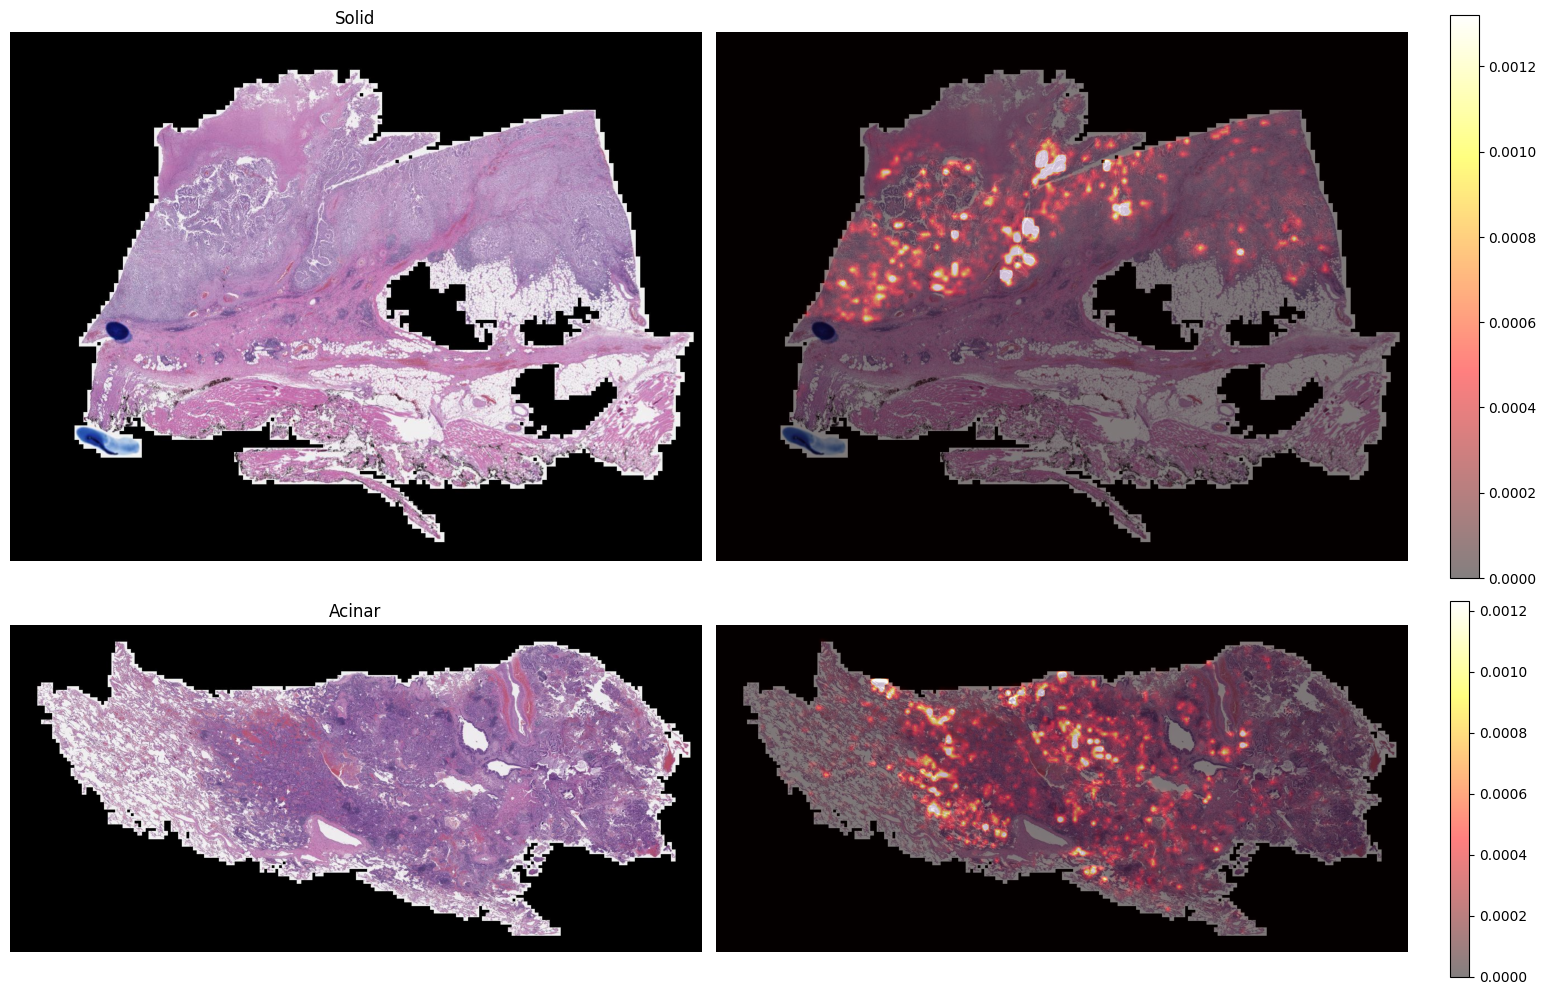

In [24]:
################################################################
############################ TEST ##############################
################################################################

plot_attention(model, test_loader)

* **Q5 (1 pt)**: From the visualization above, what can you interpret?
    * **Answer**: The attention map visualizes where the attention-based model is "focusing" when making predictions about tumor images. The hot spots